# 222. Count Complete Tree Nodes
https://leetcode.com/problems/count-complete-tree-nodes/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Binary search + height | $O(\log^2 n)$ | $O(\log n)$ | Optimal — exploit completeness |
| Full traversal | $O(n)$ | $O(\log n)$ | Visit every node |

## Methodology

A complete binary tree has all levels full except possibly the last. Compare left and right subtree heights. If equal, the left subtree is perfect (has $2^h - 1$ nodes), so count it directly and recurse on the right. If unequal, the right subtree is a perfect tree of one less height, so count it directly and recurse on the left. Each recursion descends one level, and height computation is O(log n), giving O(log^2 n) total.

## Solutions

### C#

In [ ]:
public class Solution {
    public int CountNodes(TreeNode root) {
        if (root == null) return 0;
        int leftH = Height(root.left);
        int rightH = Height(root.right);
        if (leftH == rightH)
            return (1 << leftH) + CountNodes(root.right);
        else
            return (1 << rightH) + CountNodes(root.left);
    }

    private int Height(TreeNode node) {
        int h = 0;
        while (node != null) { h++; node = node.left; }
        return h;
    }
}

### Python

In [ ]:
class Solution:
    def countNodes(self, root: Optional[TreeNode]) -> int:
        if not root:
            return 0

        def height(node):
            h = 0
            while node:
                h += 1
                node = node.left
            return h

        left_h = height(root.left)
        right_h = height(root.right)
        if left_h == right_h:
            return (1 << left_h) + self.countNodes(root.right)
        else:
            return (1 << right_h) + self.countNodes(root.left)

### Go

In [ ]:
func countNodes(root *TreeNode) int {
    if root == nil {
        return 0
    }
    leftH := height(root.Left)
    rightH := height(root.Right)
    if leftH == rightH {
        return (1 << leftH) + countNodes(root.Right)
    }
    return (1 << rightH) + countNodes(root.Left)
}

func height(node *TreeNode) int {
    h := 0
    for node != nil {
        h++
        node = node.Left
    }
    return h
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn count_nodes(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        match root {
            None => 0,
            Some(node) => {
                let n = node.borrow();
                let left_h = Self::height(&n.left);
                let right_h = Self::height(&n.right);
                if left_h == right_h {
                    (1 << left_h) + Self::count_nodes(n.right.clone())
                } else {
                    (1 << right_h) + Self::count_nodes(n.left.clone())
                }
            }
        }
    }

    fn height(node: &Option<Rc<RefCell<TreeNode>>>) -> i32 {
        let mut h = 0;
        let mut curr = node.clone();
        while let Some(n) = curr {
            h += 1;
            curr = n.borrow().left.clone();
        }
        h
    }
}

## Example Scenarios

### 1. Common Case — Complete Tree with 6 Nodes
**Input:** `root = [1, 2, 3, 4, 5, 6]`

At root: left height (2) differs from right height (1), so the right subtree is perfect with $2^1 - 1 = 1$ node plus root contribution: $2^1 = 2$. Recurse on the left subtree. At node 2: equal heights, left is perfect ($2^1 = 2$ nodes), recurse right. Total: $2 + 2 + 1 + 1 = 6$.

WHY tricky: The algorithm decides which subtree to **skip** (perfect) vs. recurse into based on height comparison. Only $O(\log n)$ recursive calls, each with $O(\log n)$ height computation.

$T(n) = T(n/2) + O(\log n) = O(\log^2 n)$. Three recursive calls for $n = 6$. **Output:** `6`

---

### 2. Slightly Complex — Perfect Binary Tree
**Input:** `root = [1, 2, 3, 4, 5, 6, 7]`

At every node, left height equals right height, meaning one subtree is always immediately countable as $2^h$ nodes. The algorithm resolves it in $O(\log n)$ calls because it never needs to explore both subtrees.

WHY tricky: A perfect tree is the **best case** — each call skips half the tree. Total nodes = $2^h - 1 = 2^3 - 1 = 7$.

Perfect tree: $n = 2^h - 1 = 7$. Only $O(\log n) = 3$ calls. **Output:** `7`

---

### 3. Edge Case: Time — Maximum Depth, Last Node Leftmost
**Input:** Complete tree with $2^{20} = 1{,}048{,}576$ nodes (last level has exactly 1 node)

Height is 20. Each recursive call computes height in $O(20) = O(\log n)$. The algorithm makes at most 20 recursive calls, giving $O(\log^2 n) = O(400)$ operations total. A naive full traversal would be $O(n) = O(10^6)$.

WHY tricky: Worst case for the optimal algorithm — at every level, heights differ, forcing recursion deeper. But $O(\log^2 n)$ is still dramatically better than $O(n)$.

$T = O(\log^2 n) = O(20^2) = O(400)$ operations. Naive: $O(2^{20}) = 10^6$. **Output:** `1048576`

---

### 4. Edge Case: Space — Single Node
**Input:** `root = [1]`

A single node has left_h = right_h = 0. Since they are equal, the left subtree is "perfect" with $2^0 = 1$ node. Recurse right (null), returning 0. Total = 1. Minimal recursion depth and stack usage.

WHY tricky: Tests the base case of the height-comparison logic. Stack depth is $O(\log 1) = O(1)$. Only one call needed.

Stack depth: $O(1)$. One call, no further recursion. **Output:** `1`

---

### 5. Almost Impossible — Empty Tree (Null Root)
**Input:** `root = []` (null)

The root is null, so the base case returns 0 immediately. No height computation, no recursion. This is the degenerate case that must be handled to avoid null pointer exceptions.

WHY tricky: The null check must come **before** any height computation or child access. Forgetting this causes NullPointerException/segfault. Zero nodes is a valid complete tree.

$\text{countNodes}(\text{null}) = 0$. Time: $O(1)$. Space: $O(1)$. **Output:** `0`

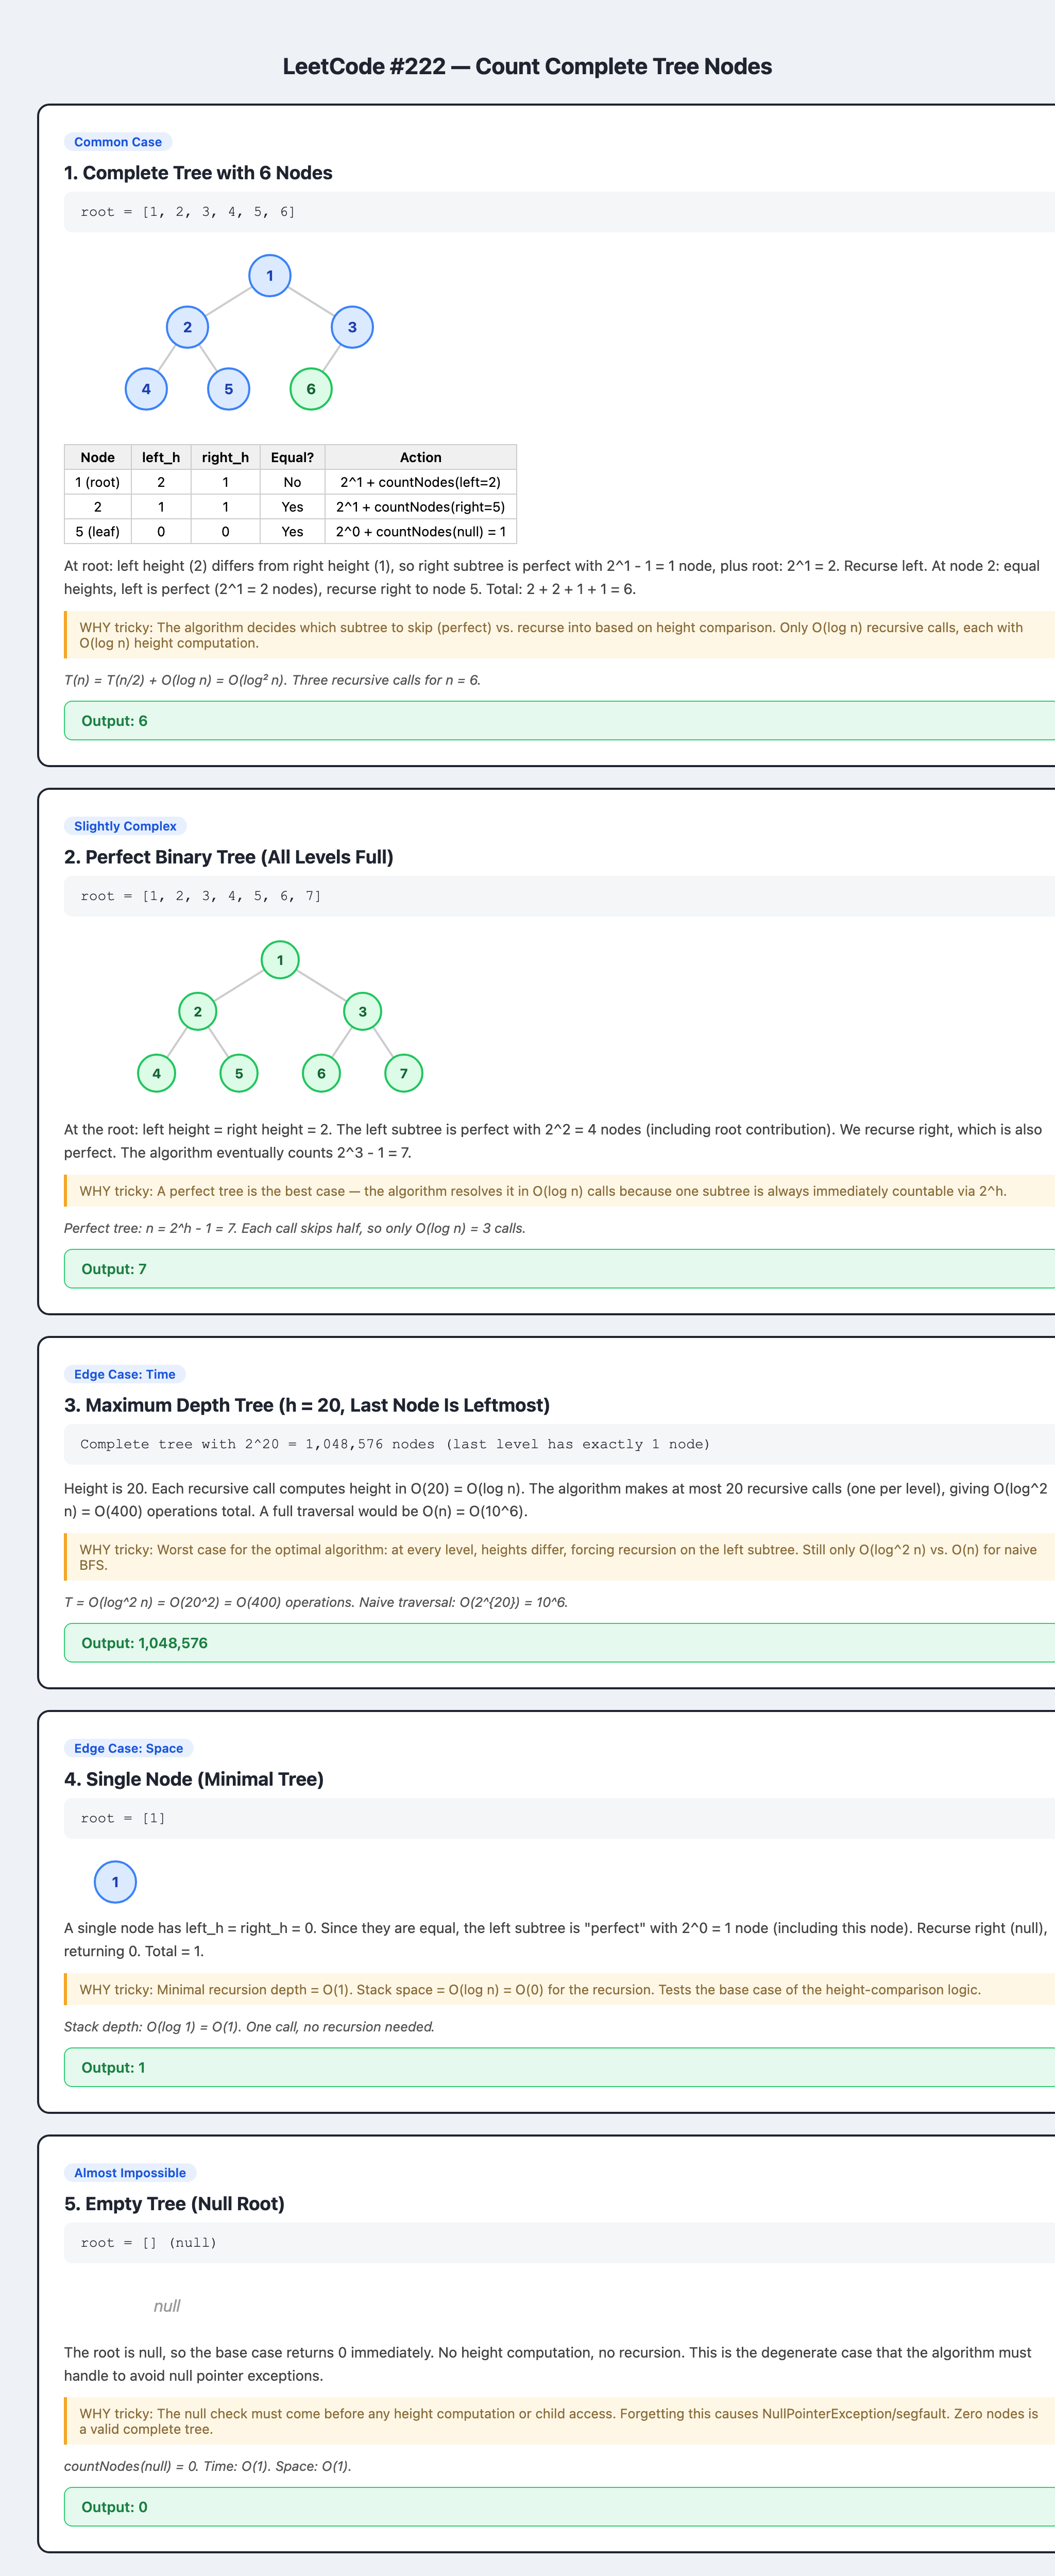